In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        print(file_path)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/firomsamohammedsani/ames-housing-dataset/AmesHousing.csv


# Ames Housing — Advanced Multidimensional Data Analysis

In this notebook, we explore the Ames Housing dataset to uncover meaningful insights using Python, statistics, and advanced analysis techniques.

We will go beyond basic summaries by applying:
- Exploratory Data Analysis (EDA)
- Correlation & Crosstabs
- Percentile & Distribution Analysis
- Cohort & Ratio Analysis
- Dimensionality Reduction (PCA)

The goal is to identify the key drivers of house prices and understand multi-dimensional relationships within the data.

In [2]:
df = pd.read_csv(file_path)
df.head

<bound method NDFrame.head of       Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL           NaN      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

     Alle

## Data Understanding & Initial Inspection

We begin by understanding the structure of the dataset. This includes:
- Total number of rows and columns
- Column names and data types
- Identifying missing values
- Getting a first look at numeric distributions

This helps guide our cleaning and analysis steps.

In [3]:
# Check dataset size
print("Shape:", df.shape)

# Show column names
print(df.columns.tolist())

# Overview of column types
df.info()

# Summary statistics for numeric columns
df.describe()

Shape: (2930, 82)
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved D

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [4]:
# Count missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
dtype: int64

## Data Cleaning

We remove columns with excessive missing values and fill numeric missing values with the median.  
This preserves data while reducing noise.

In [22]:
# Drop columns with more than 30% missing data
threshold = len(df) * 0.7
df = df.dropna(axis=1, thresh=threshold)

# Fill missing numeric values with median
num_cols = df.select_dtypes(include='number').columns
df.loc[:,num_cols] = df[num_cols].fillna(df[num_cols].median())

# Verify remaining missing values
df.isnull().sum().sort_values(ascending=False).head(10)

Garage Cond       159
Garage Finish     159
Garage Qual       159
Garage Type       157
Bsmt Exposure      83
BsmtFin Type 2     81
Bsmt Cond          80
Bsmt Qual          80
BsmtFin Type 1     80
Electrical          1
dtype: int64

## Exploratory Data Analysis (EDA)

Now that the dataset is clean, we begin exploring relationships between variables.

Goals:
- Understand the distribution of the target variable (SalePrice)
- Identify patterns in numerical features
- Explore relationships using correlation
- Begin forming hypotheses about what drives house prices

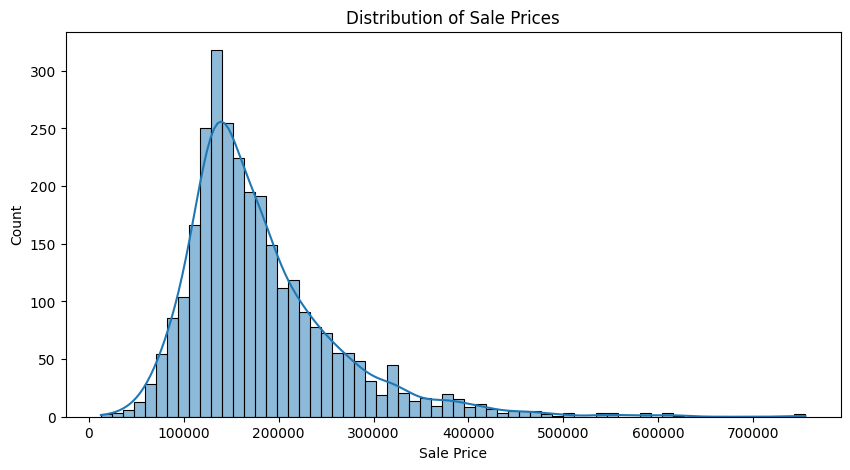

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

### Insight:
The sale price distribution is right-skewed, meaning most houses sell at lower prices while a smaller number of houses sell at very high prices. This suggests the presence of luxury properties that may behave differently from average homes.

### Correlation Analysis

To understand which features influence house prices, we examine the correlation between numeric features and SalePrice.

In [7]:
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.head(15)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647812
Garage Area       0.640381
Total Bsmt SF     0.632164
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.508882
Mas Vnr Area      0.502196
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432862
Name: SalePrice, dtype: float64

### Insight:
Features such as Overall Quality, Living Area, and Garage Cars have strong positive correlation with SalePrice. This suggests that structural quality and usable living space are major price drivers.

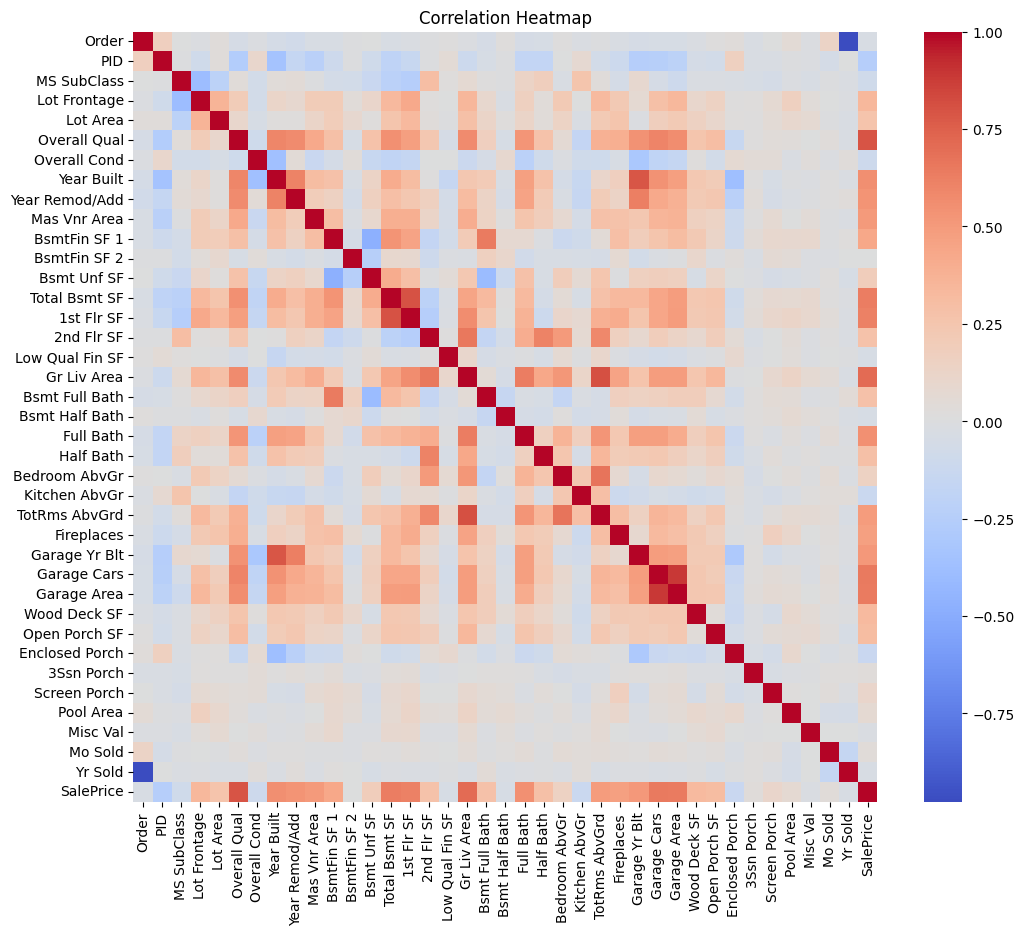

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight:
Several structural and quality-related variables are strongly correlated with each other (multicollinearity). This is important because it can affect regression models later.

## Cross-Tabulation & Categorical Analysis

Numerical correlations are useful, but many important features in this dataset are categorical.

In this step, we explore relationships between categorical variables and house prices using:
- Cross-tabulation
- Grouped averages
- Category-based comparisons

This helps us understand how different groups of houses behave.

In [9]:
neighborhood_price = df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)
neighborhood_price.head(10)

Neighborhood
NoRidge    330319.126761
StoneBr    324229.196078
NridgHt    322018.265060
GrnHill    280000.000000
Veenker    248314.583333
Timber     246599.541667
Somerst    229707.324176
ClearCr    208662.090909
Crawfor    207550.834951
CollgCr    201803.434457
Name: SalePrice, dtype: float64

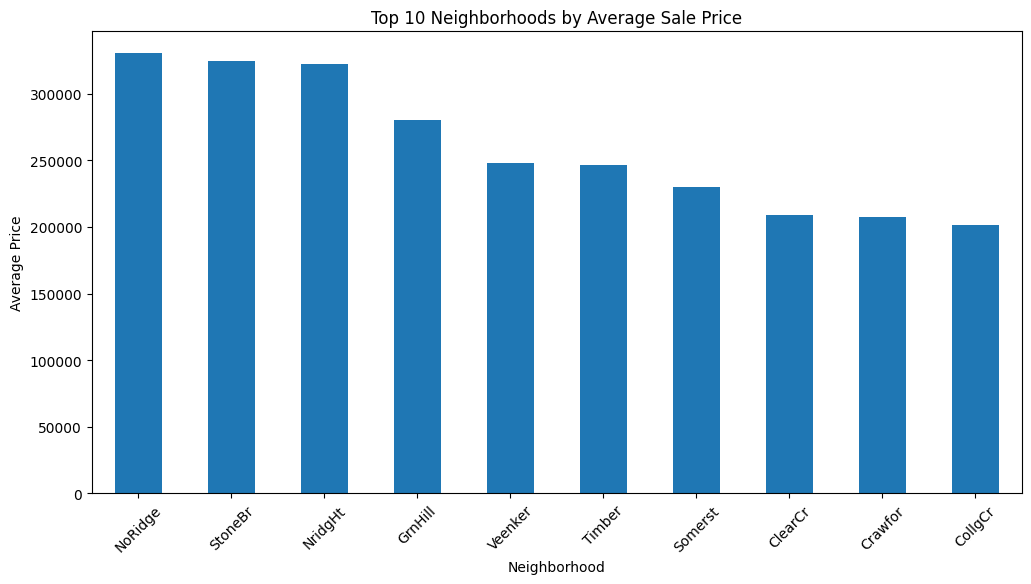

In [10]:
plt.figure(figsize=(12,6))
neighborhood_price.head(10).plot(kind="bar")
plt.title("Top 10 Neighborhoods by Average Sale Price")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

### Insight:
There is a significant variation in house prices across neighborhoods. This suggests that location plays a major role in determining property value, likely due to factors such as infrastructure, accessibility, and desirability.

In [11]:
pd.crosstab(df["Neighborhood"], df["Overall Qual"])

Overall Qual,1,2,3,4,5,6,7,8,9,10
Neighborhood,,,,,,,,,,
Blmngtn,0,0,0,0,0,0,24,4,0,0
Blueste,0,0,0,0,0,7,0,3,0,0
BrDale,0,0,0,0,8,22,0,0,0,0
BrkSide,1,1,6,14,47,32,7,0,0,0
ClearCr,0,0,0,3,11,15,14,1,0,0
CollgCr,0,0,0,2,51,39,122,45,8,0
Crawfor,0,0,0,3,24,34,26,16,0,0
Edwards,1,1,7,51,77,43,10,0,1,3
Gilbert,0,0,0,1,7,74,73,9,1,0


### Insight:
Certain neighborhoods tend to have consistently higher-quality homes. This indicates that location and construction quality are not independent, reinforcing the idea that premium areas maintain higher building standards.

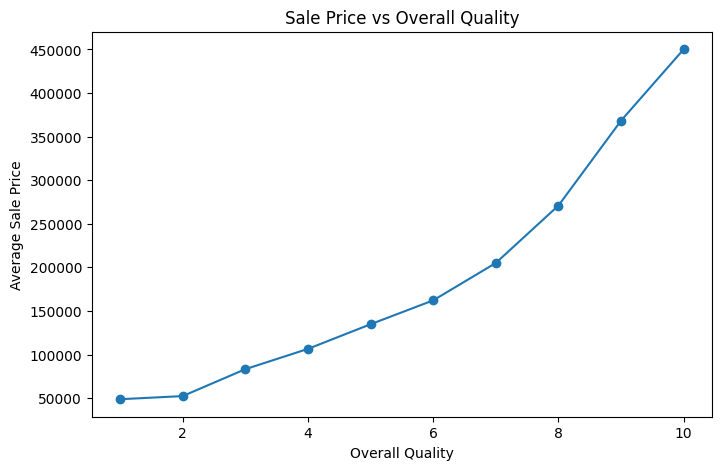

In [12]:
quality_price = df.groupby("Overall Qual")["SalePrice"].mean()

plt.figure(figsize=(8,5))
quality_price.plot(marker='o')
plt.title("Sale Price vs Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Average Sale Price")
plt.show()

### Insight:
Sale price increases almost linearly with overall quality. This indicates that perceived construction quality is one of the strongest determinants of housing prices.

In [13]:
pivot = df.pivot_table(values="SalePrice", index="Neighborhood", columns="Overall Qual", aggfunc="mean")
pivot.head()

Overall Qual,1,2,3,4,5,6,7,8,9,10
Neighborhood,,,,,,,,,,
Blmngtn,NaN,NaN,NaN,NaN,NaN,NaN,192019.416667,224515.25,NaN,NaN
Blueste,NaN,NaN,NaN,NaN,NaN,126914.285714,NaN,182500.00,NaN,NaN
BrDale,NaN,NaN,NaN,NaN,115968.750000,101840.909091,NaN,NaN,NaN,NaN
BrkSide,39300.0,60000.0,67416.666667,98892.857143,123882.978723,143964.843750,165142.857143,NaN,NaN,NaN
ClearCr,NaN,NaN,NaN,183977.333333,163000.000000,207960.000000,245557.142857,279000.00,NaN,NaN


### Insight:
Even within the same quality level, prices vary across neighborhoods. This confirms that both location and quality independently contribute to house prices.

## Percentile Analysis & Feature Engineering

In this step, we go beyond raw variables by:
- Segmenting houses into price groups using percentiles
- Creating new features (ratios) to better understand value

This allows deeper insights into how different types of houses behave across multiple dimensions.

In [23]:
df.loc[:,"Price_Category"] = pd.qcut(df["SalePrice"], 4, labels=["Low", "Mid-Low", "Mid-High", "High"])

df[["SalePrice", "Price_Category"]].head()

,SalePrice,Price_Category
0,215000,High
1,105000,Low
2,172000,Mid-High
3,244000,High
4,189900,Mid-High


In [24]:
df.groupby("Price_Category",observed = False)[["Gr Liv Area", "Overall Qual", "Garage Cars"]].mean()

,Gr Liv Area,Overall Qual,Garage Cars
Price_Category,,,
Low,1116.142084,4.792963,1.105548
Mid-Low,1313.956044,5.502747,1.550824
Mid-High,1567.844262,6.420765,1.964481
High,2004.161423,7.674419,2.452804


### Insight:
Higher-priced houses are not just slightly better — they are significantly larger, have higher construction quality, and more garage capacity.

This indicates that house pricing is driven by a combination of multiple reinforcing factors rather than a single variable.

In [25]:
df.loc[:,"Price_per_sqft"] = df["SalePrice"] / df["Gr Liv Area"]

df[["SalePrice", "Gr Liv Area", "Price_per_sqft"]].head()

,SalePrice,Gr Liv Area,Price_per_sqft
0,215000,1656,129.830918
1,105000,896,117.187500
2,172000,1329,129.420617
3,244000,2110,115.639810
4,189900,1629,116.574586


In [17]:
df.groupby("Neighborhood")["Price_per_sqft"].mean().sort_values(ascending = False).head(10)

Neighborhood
GrnHill    198.656617
Greens     168.835142
StoneBr    166.063367
NridgHt    165.565534
Timber     144.740459
Somerst    143.672789
Veenker    143.231669
Blmngtn    140.088760
CollgCr    137.370426
NoRidge    132.382209
Name: Price_per_sqft, dtype: float64

### Insight:
Some neighborhoods have higher price per square foot, indicating premium pricing beyond just house size.

This suggests that location adds intrinsic value, possibly due to demand, amenities, or prestige.

In [26]:
df.groupby("Price_Category" , observed = False)["Price_per_sqft"].mean()

Price_Category
Low          99.822221
Mid-Low     116.683460
Mid-High    121.545430
High        147.379165
Name: Price_per_sqft, dtype: float64

### Insight:
Higher-priced houses also tend to have higher price per square foot, meaning they are not only larger but also more expensive per unit area.

This indicates a compounding effect of luxury, where premium homes command disproportionately higher value.

## Cohort Analysis & Time-Based Trends

In this step, we analyze how house prices evolve over time by grouping houses into cohorts based on their construction year.

This helps us understand:
- How property value changes across different building eras
- Whether newer houses command higher prices
- Long-term trends in housing valuation

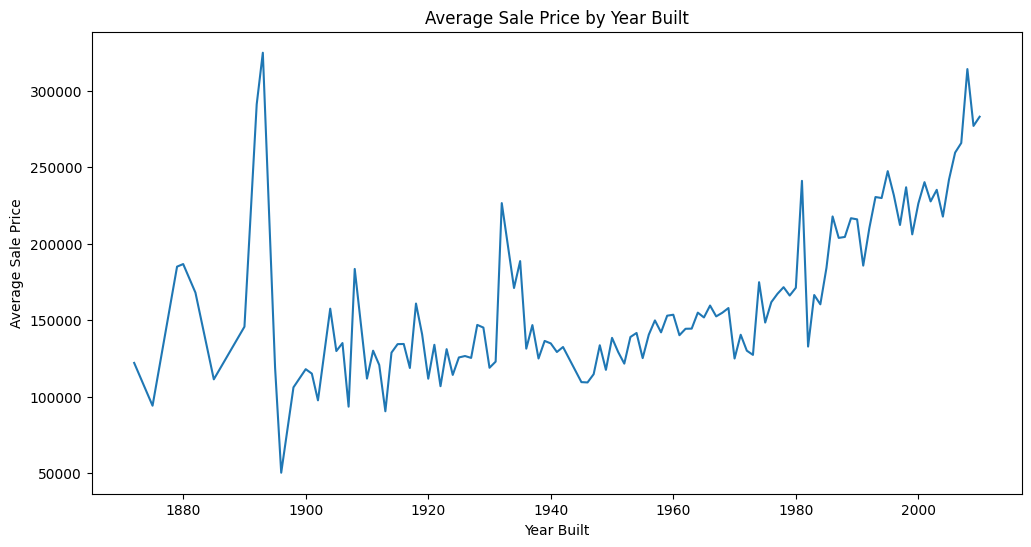

In [19]:
year_price = df.groupby("Year Built")["SalePrice"].mean()

plt.figure(figsize=(12,6))
year_price.plot()
plt.title("Average Sale Price by Year Built")
plt.xlabel("Year Built")
plt.ylabel("Average Sale Price")
plt.show()

### Insight:
Newer houses tend to have higher average sale prices, indicating that modern construction, updated designs, and newer materials contribute to increased property value.

In [28]:
df.loc[ : ,"Year_Group"] = pd.cut(
    df["Year Built"],
    bins=[1870, 1940, 1970, 2000, 2025],
    labels=["Old", "Mid-Old", "Modern", "New"]
)

df.groupby("Year_Group" , observed = False)["SalePrice"].mean()

Year_Group
Old        129960.727273
Mid-Old    141547.455504
Modern     191668.434466
New        249967.949660
Name: SalePrice, dtype: float64

### Insight:
There is a clear step-wise increase in price from older to newer cohorts. This suggests that buyers place a premium on newer homes, likely due to reduced maintenance costs and modern features.

In [21]:
pivot = df.pivot_table(
    observed=False,
    values="SalePrice",
    index="Year_Group",
    columns="Overall Qual",
    aggfunc="mean"
)

pivot

Overall Qual,1,2,3,4,5,6,7,8,9,10
Year_Group,,,,,,,,,,
Old,61000.000000,50279.777778,77994.791667,97916.271605,122039.158730,142471.330986,173976.410714,233390.461538,NaN,400000.00
Mid-Old,44633.333333,56927.750000,90972.750000,110030.810345,136540.164859,163609.254717,204941.463415,268000.000000,NaN,NaN
Modern,NaN,NaN,NaN,113142.222222,141523.461538,167358.989691,214274.798165,265007.327586,348172.333333,617500.00
New,NaN,NaN,NaN,158000.000000,162249.947368,173124.551724,204070.811847,276258.327273,370883.852632,427469.48


### Insight:
Even within the same construction period, higher-quality homes command significantly higher prices. This confirms that both time (modernity) and quality independently influence property value.